## Imports and paths

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import FlatLambdaCDM

from pyLensLib.compositeModel import compositeModel
from pyLensLib.nfwell import nfwell
from pyLensLib.sersic import sersic
from pyLensLib.sie import sie

%matplotlib inline

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

outdir = project_root / "outputs"
outdir.mkdir(exist_ok=True)

outdir

/home/sabrina-n/tesi-triennale/.venv/lib/python3.10/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


PosixPath('/home/sabrina-n/tesi-triennale/outputs')

## Cosmology and image grid

In [2]:
co = FlatLambdaCDM(H0=70.0, Om0=0.3)
zl = 0.5 # 0.5, 0.2 
zs = 2.0 # 0.5: 2 o 1.5 , 0.2: 1

fov = 6.0 # field of view, defines the resolution of the image
npix = 220 # number of pixels in the image
theta = np.linspace(-fov / 2.0, fov / 2.0, npix) # defines the angle on the image plane based on the previous fov, with the origin at the center
extent = [-fov / 2.0, fov / 2.0, -fov / 2.0, fov / 2.0] # defines the dimension of the panels in the images, fixed for most of them

## NUMERICAL CHECKS ##
print(f"Grid: {npix} x {npix} pixels over {fov:.1f} arcsec")
print(f"Lens redshift: {zl:.2f}; source redshift: {zs:.2f}")

Grid: 220 x 220 pixels over 6.0 arcsec
Lens redshift: 0.50; source redshift: 2.00


# Variation of Sigma0

## Define the SIE lens, lens the source and add lens-galaxy light
 

In [ ]:
sigma0_values = [180, 250, 290]
total_images_sigma = []
kappa_maps = []
critical_lines_all = []
einstein_radii = []

source_kwargs = {
    "n": 1.0, # Sérsic index
    "re": 0.15, # effective radius, enclosing half of the total light
    "q": 0.7, # ellipticity of the source
    "pa": np.deg2rad(20.0),
    "ys1": 0.06, # source coordinates; changing them modifies the image morphology
    "ys2": 0.03,  
    "flux": 1.0e4,
    "zs": zs,
}

lens_light_kwargs = {
    "n": 4.0,
    "re": 0.55,
    "q": 0.75,
    "pa": np.deg2rad(35.0),
    "ys1": 0.0,
    "ys2": 0.0,
    "flux": 3.0e4,
    "zs": zl,
 }

lens_light = sersic(size=fov, Npix=npix, gl=None, **lens_light_kwargs) # Adds the lens-galaxy light using a second Sérsic profile

for i, sigma0 in enumerate(sigma0_values):
 lens_var = sie(
     co,
     zl=zl, # lens redshift 
     zs=zs, # source redshift; must be greater than zl
     sigma0=sigma0, # central velocity dispersion, related to the lens mass
     q=0.75, # ellipticity of the lens
     pa=np.deg2rad(35.0), # position angle of the major axis, specified in degrees and converted to radians
     theta_c=1.0e-4, # core radius, if 0 the profile becomes singular
     x1=0.0, # lens coordinates; usually set to the origin for visualization
     x2=0.0,
 )
 lens_var.setGrid(theta=theta)
 
 critical_lines = [lens_var.getCritPoints(cl) for cl in lens_var.tancl()]
 critical_lines_all.append(critical_lines)

 einstein_radii.append(lens_var.bsie())
 kappa_maps.append(lens_var.ka)

# Lensing of a Sérsic source through the defined lens model
 source = sersic(size=fov, Npix=npix, gl=lens_var, save_unlensed=True, **source_kwargs) 

 total_image = source.image + lens_light.image
 total_images_sigma.append(total_image.copy())


## Visualize the lensing configuration

Einstein radius for sigma_0=180: 0.6855653958582628 arcsec
Einstein radius for sigma_0=250: 1.322464112380908 arcsec
Einstein radius for sigma_0=290: 1.77950770961975 arcsec


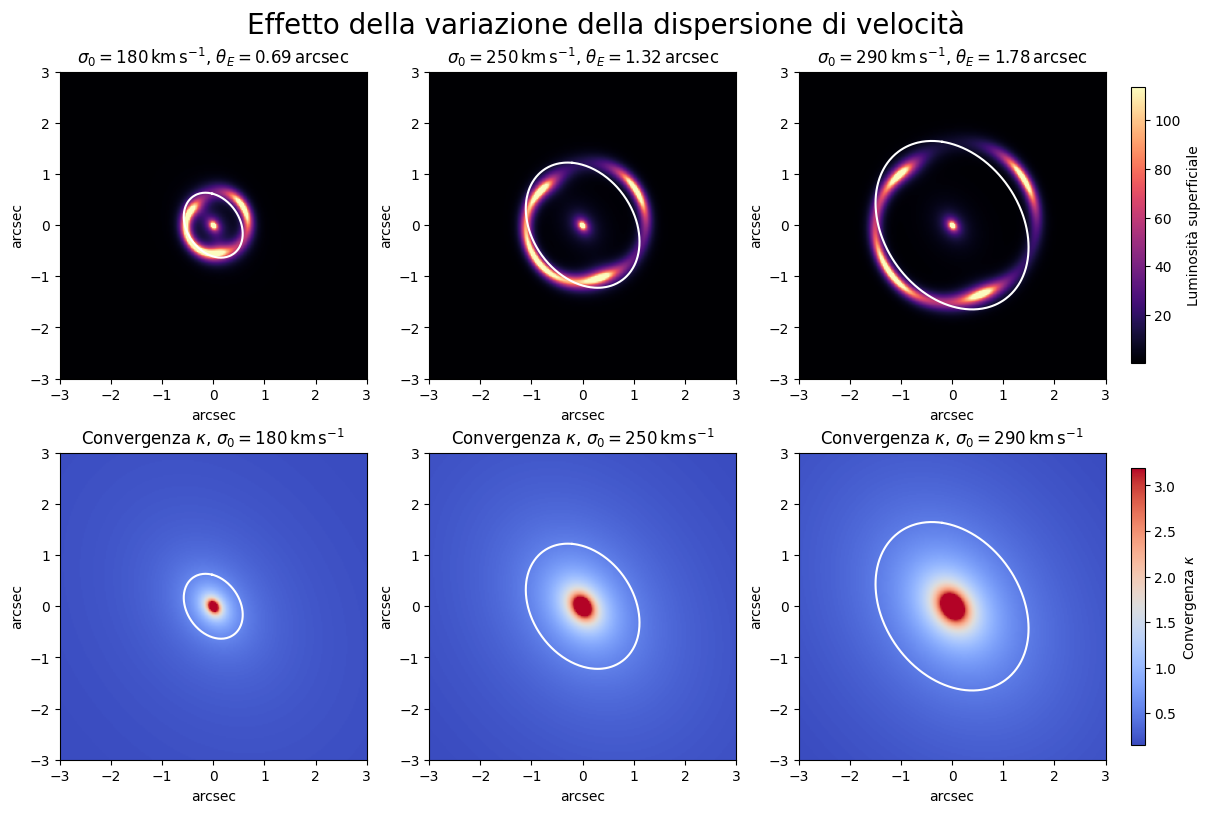

In [ ]:
# Compute a common display vmax using a high-percentile value across a collection of images
def percentile_vmax(images, percentile=99.5):
    return max(
        np.percentile(img[np.isfinite(img)], percentile)
        for img in images
    )

vmax_image_sigma = percentile_vmax(total_images_sigma)
vmax_kappa_sigma = percentile_vmax(kappa_maps)

fig1, ax1 = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)

# Effect of varying the velocity dispersion
fig1.suptitle("Effetto della variazione della dispersione di velocità", fontsize=20) 

for i, sigma0 in enumerate(sigma0_values):
    im0 = ax1[0,i].imshow(total_images_sigma[i], origin="lower", extent=extent, cmap="magma", vmax=vmax_image_sigma)
    ax1[0,i].set_xlabel("arcsec")
    ax1[0,i].set_ylabel("arcsec")

    im1 = ax1[1,i].imshow(kappa_maps[i], origin="lower", extent=extent, cmap="coolwarm", vmax=vmax_kappa_sigma)
    ax1[1,i].set_xlabel("arcsec")
    ax1[1,i].set_ylabel("arcsec")

    ax1[0,i].set_title(
    rf'$\sigma_0={sigma0}\,\mathrm{{km\,s^{{-1}}}}$, '
    rf'$\theta_E={einstein_radii[i]:.2f}\,\mathrm{{arcsec}}$')
    ax1[1,i].set_title(
    rf'Convergenza $\kappa$, $\sigma_0={sigma0}\,\mathrm{{km\,s^{{-1}}}}$') # convergence, with associated value of sigma0

    # Numerical check
    print(f"Einstein radius for sigma_0={sigma0}: {einstein_radii[i]} arcsec") 

    for xcrit, ycrit in critical_lines_all[i]:
            ax1[0,i].plot(xcrit, ycrit, color="white")
            ax1[1,i].plot(xcrit, ycrit, color="white")
    
for ax in ax1.flat:
    ax.set_aspect("equal")

# Surface brightness
cbar0 = fig1.colorbar(
    im0,
    ax=ax1[0, :],
    shrink=0.85,
    pad=0.02
)
cbar0.set_label("Luminosità superficiale")

# Convergence
cbar1 = fig1.colorbar(
    im1,
    ax=ax1[1, :],
    shrink=0.85,
    pad=0.02
)
cbar1.set_label(r"Convergenza $\kappa$")


## Saving

In [ ]:
figure_path = outdir / "final_simulations_sigma0.png" # Change the filename if you do not want to overwrite the existing file!
fig1.savefig(figure_path, dpi=180)
print(f"Saved {figure_path}") # Save the figure

Saved /home/sabrina-n/tesi-triennale/outputs/final_simulations_sigma0.png


# Source-lens misalignment


## Define the SIE lens, lens the source, add lens-galaxy light
 

In [ ]:
positions = [(0.01, 0.03), (0.15, 0.1), (-0.15,0.05), (0.3, 0.3)]

lensed_images_positions = []
unlensed_images = []

lens = sie(
     co,
     zl=zl,
     zs=zs, 
     sigma0=260.0,
     q=0.75, 
     pa=np.deg2rad(35.0), 
     theta_c=1.0e-4, 
     x1=0.0,
     x2=0.0,
 )
lens.setGrid(theta=theta)

critical_lines_lens = [lens.getCritPoints(cl) for cl in lens.tancl()]
caustics = lens.getCaustics(lens.tancl())
caustic_points_all = [
    np.column_stack(lens.getCausticPoints(cau))
    for cau in caustics
]
einstein_radius = lens.bsie()

# Numerical check
print(f"Einstein radius: {einstein_radius} arcsec") 

for i, position in enumerate(positions):
 
 source_kwargs_var = {
    "n": 1.0,
    "re": 0.15,
    "q": 0.7,
    "pa": np.deg2rad(20.0),
    "ys1": position[0], 
    "ys2": position[1],
    "flux": 1.0e4,
    "zs": zs,
}

 source_var = sersic(size=fov, Npix=npix, gl=lens, save_unlensed=True, **source_kwargs_var)
 unlensed_images.append(source_var.image_unlensed)
 source_image = source_var.image
 lensed_images_positions.append(source_image.copy())


Einstein radius: 1.43037718395119 arcsec


## Visualize the lensing configuration

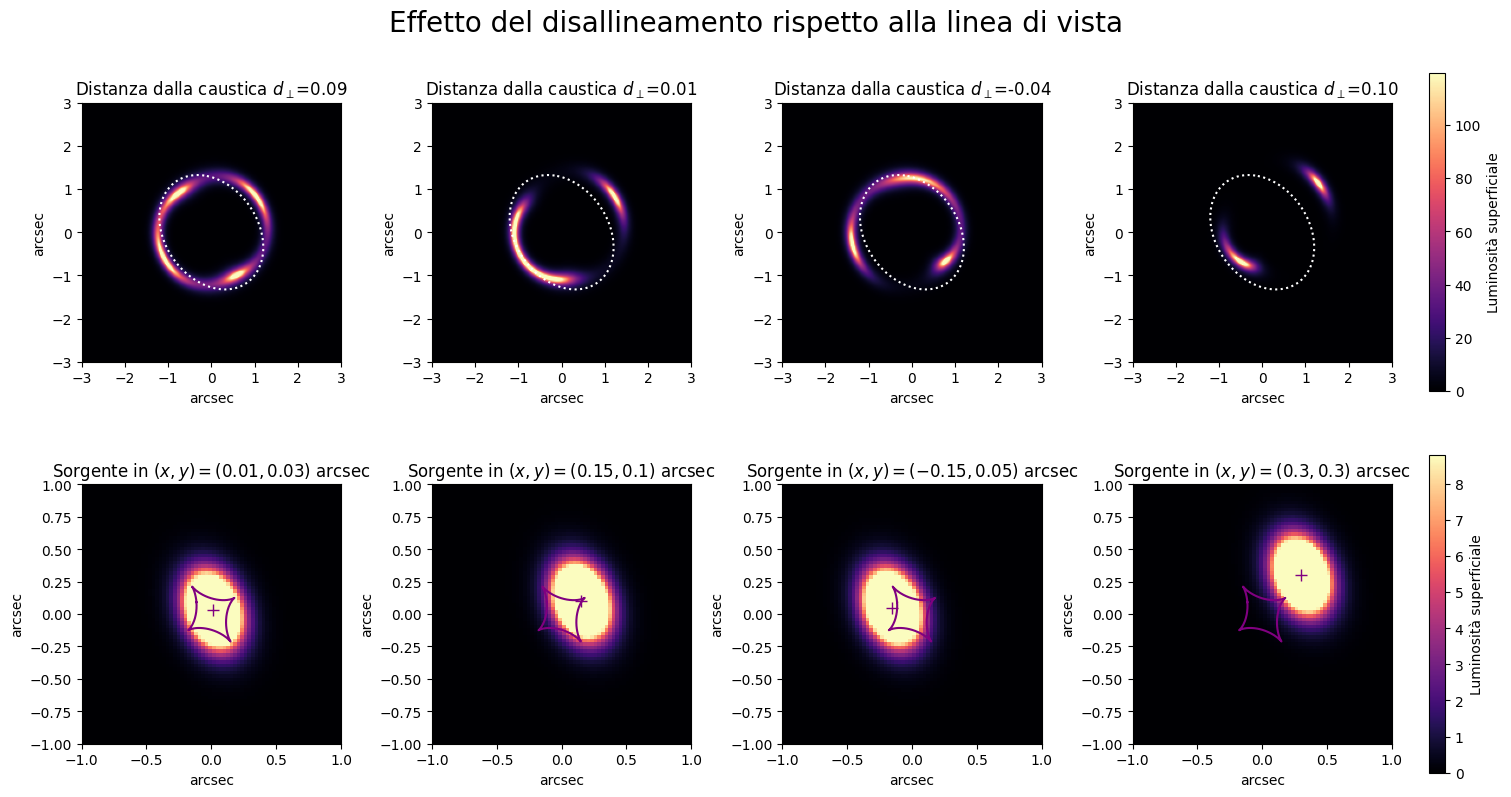

In [ ]:
d_caustic_all = []
vmax_image2 = percentile_vmax(lensed_images_positions)
vmax_unlensed = percentile_vmax(unlensed_images)

fig2, ax2 = plt.subplots(2, 4, figsize=(15, 8), constrained_layout=True)

# Effect of varying the source position relative to the line of sight
fig2.suptitle("Effetto del disallineamento rispetto alla linea di vista", fontsize = 20)

for i, position in enumerate(positions):
    for xcrit, ycrit in critical_lines_lens:
                ax2[0,i].plot(xcrit, ycrit, color="white", linestyle= "dotted")
        
    distances = []
    
    for caustic_points in caustic_points_all:
            xcau = caustic_points[:, 0]
            ycau = caustic_points[:, 1]

            # Draw the caustic 
            ax2[1, i].plot(xcau, ycau, color="purple")
    
            # Distance from the source to each caustic point
            dists = np.linalg.norm(caustic_points - position, axis=1)
    
            # Closest point on the caustic to the source
            j = np.argmin(dists)
            x0 = xcau[j]
            y0 = ycau[j]
    
            # Local tangent to the caustic
            dx = np.gradient(xcau)
            dy = np.gradient(ycau)
            tangent = np.array([dx[j], dy[j]])
    
            # Normalize the tangent
            tangent /= np.linalg.norm(tangent)
    
            # Normal to the caustic
            normal = np.array([-tangent[1], tangent[0]])
    
            # Vector from the caustic point to the source
            delta = position - np.array([x0, y0])
    
            # Signed distance along the normal direction
            d_normal = np.dot(delta, normal)
            distances.append(d_normal)
            
    # Signed normal distance to the closest caustic
    d_caustic = min(distances, key=abs)
    d_caustic_all.append(d_caustic)
    
    im0 = ax2[0,i].imshow(lensed_images_positions[i], origin="lower", extent=extent, cmap="magma", vmax=vmax_image2)
    ax2[0,i].set_xlabel("arcsec")
    ax2[0,i].set_ylabel("arcsec")

    im1 = ax2[1,i].imshow(unlensed_images[i], origin="lower", extent=extent, cmap="magma", vmax=vmax_unlensed)
    ax2[1,i].set_xlim(-1, 1)
    ax2[1,i].set_xlabel("arcsec")
    ax2[1,i].set_ylim(-1, 1)
    ax2[1,i].set_ylabel("arcsec")
    

    # Signed normal distance from the closest caustic
    ax2[0,i].set_title(f'Distanza dalla caustica $d_\perp$={d_caustic_all[i]:.2f}')

    # Source coordinates
    ax2[1,i].set_title(rf'Sorgente in $(x,y)={position}$ arcsec')

    # Marker at the source center
    ax2[1,i].plot(position[0], position[1], marker='+', color='purple', markersize=8)

for ax in ax2.flat:
    ax.set_aspect("equal")


# Surface brightness, for both
cbar0 = fig2.colorbar(
    im0,
    ax=ax2[0, :],
    shrink=0.85,
    pad=0.02
)
cbar0.set_label("Luminosità superficiale")

cbar1 = fig2.colorbar(
    im1,
    ax=ax2[1, :],
    shrink=0.85,
    pad=0.02
)
cbar1.set_label("Luminosità superficiale")

# If you want to label the panels, uncomment this
# labels_a = ["(1a)", "(2a)", "(3a)", "(4a)"]
# labels_b = ["(1b)", "(2b)", "(3b)", "(4b)"]

# for i, lab in enumerate(labels_a):
#     ax2[0,i].text(
#         0.03, 0.95,
#         lab,
#         transform=ax2[0,i].transAxes,
#         color="white",
#         fontsize=12,
#         fontweight="bold",
#         va="top"
#     )

# for i, lab in enumerate(labels_b):
#     ax2[1,i].text(
#         0.03, 0.95,
#         lab,
#         transform=ax2[1,i].transAxes,
#         color="white",
#         fontsize=12,
#         fontweight="bold",
#         va="top"
#     )


## Saving

In [78]:
figure_path2 = outdir / "final_simulations_positions.png" # Change the filename if you do not want to overwrite the existing file!
fig2.savefig(figure_path2, dpi=180)
print(f"Saved {figure_path2}")

Saved /home/sabrina-n/tesi-triennale/outputs/final_simulations_positions.png


## Numerical checks

In [79]:
print("max total_images_2 (no lens)=", np.max([np.nanmax(img) for img in lensed_images_positions]))
print("max unlensed_images =", np.max([np.nanmax(img) for img in unlensed_images]))

print("source lensed image: ", np.nanmax(source.image))
print("source unlensed image: ", np.nanmax(source.image_unlensed))
print("lens light: ", np.nanmax(lens_light.image))
print("total image: ", np.nanmax(total_image))


max total_images_2 (no lens)= 205.81675249011104
max unlensed_images = 200.5859721221491
source lensed image:  197.7239232824507
source unlensed image:  171.35661857788332
lens light:  329.20693683791524
total image:  329.206945017168


# SIE perturbator 

# Build a composite lens model

In [ ]:
# Create a composite lens made of the main lens plus either a SIE or NFW perturber.
def make_composite_lens(
    base_lens,
    perturbation_kind,
    perturbation_kwargs,
    co,
    zl,
    zs,
    theta,
):
    if perturbation_kind == "SIE":
     perturbation = sie(
        co=co,
        zl=zl,
        zs=zs,
        **perturbation_kwargs 
    )

    if perturbation_kind == "NFW":
       perturbation = nfwell(
          co=co,
          zl=zl,
          zs=zs,
          **perturbation_kwargs 
       )
    perturbation.setGrid(theta=theta)

    composite = compositeModel(
        co,
        models=[base_lens, perturbation]
    )

    composite.zl = zl
    composite.zs = zs
    composite.dl = base_lens.dl
    composite.ds = base_lens.ds
    composite.dls = base_lens.dls
    composite.setGrid(theta=theta)

    return perturbation, composite

pert_pos = [1, -1.05]

second_sie_kwargs = {
    "sigma0": 90.0,
    "q": 0.9,
    "pa": np.deg2rad(-20.0),
    "theta_c": 1.0e-4,
    "x1": pert_pos[0], 
    "x2": pert_pos[1], 
}

second_nfw_kwargs = {
    "mass": 5.0e11, # total mass
    "conc": 11.0, # concentration
    "q": 0.95,
    "pa": np.deg2rad(-20.0),
    "x1": pert_pos[0],
    "x2": pert_pos[1],
}

## Add a second SIE mass component

In [81]:
sigma0_values_pert = [50.0, 70.0, 90.0]
second_lens_SIE_all = []
composite_lens_SIE_all = []
composite_critical_lines_SIE = []

for sigma0_pert in sigma0_values_pert:
    second_sie_kwargs_var = {
    "sigma0": sigma0_pert, 
    "q": 0.9,
    "pa": np.deg2rad(-20.0),
    "theta_c": 1.0e-4,
    "x1": pert_pos[0], 
    "x2": pert_pos[1], 
    }

    second_lens_SIE, lens_with_second_SIE = make_composite_lens(lens, "SIE", second_sie_kwargs_var, co, zl, zs, theta)

    second_lens_SIE_all.append(second_lens_SIE)
    composite_lens_SIE_all.append(lens_with_second_SIE)

    critical_lines_with_second_SIE = [lens_with_second_SIE.getCritPoints(cl) for cl in lens_with_second_SIE.tancl()]
    composite_critical_lines_SIE.append(critical_lines_with_second_SIE)

# Numerical checks:
for pert in second_lens_SIE_all:
    print(f"Added second SIE mass component at "f"({pert.x1:.2f}, {pert.x2:.2f}) arcsec")
    print(f"Second SIE Einstein radius: {pert.bsie():.3f} arcsec")


Added second SIE mass component at (1.00, -1.05) arcsec
Second SIE Einstein radius: 0.048 arcsec
Added second SIE mass component at (1.00, -1.05) arcsec
Second SIE Einstein radius: 0.095 arcsec
Added second SIE mass component at (1.00, -1.05) arcsec
Second SIE Einstein radius: 0.156 arcsec


## Ray trace with the composite lenses

In [82]:
composite_sources_all_SIE = []
composite_total_images_all_SIE = []
composite_kappa_maps_all_SIE = []

for i, pert in enumerate(second_lens_SIE_all):
    source_with_second_SIE = sersic(
    size=fov,
    Npix=npix,
    gl=composite_lens_SIE_all[i],
    save_unlensed=True,
    **source_kwargs,
    )
    composite_sources_all_SIE.append(source_with_second_SIE)
    composite_kappa_maps_all_SIE.append(composite_lens_SIE_all[i].ka)

    total_image_with_second_SIE = source_with_second_SIE.image + lens_light.image
    composite_total_images_all_SIE.append(total_image_with_second_SIE)

    # Numerical checks
    print(f"Composite-lens source flux sum: {source_with_second_SIE.image.sum():.3e}")
    print(f"Change relative to original lens: "
      f"{source_with_second_SIE.image.sum() - source.image.sum():.3e}")

Composite-lens source flux sum: 1.926e+05
Change relative to original lens: -2.266e+04
Composite-lens source flux sum: 1.860e+05
Change relative to original lens: -2.925e+04
Composite-lens source flux sum: 1.785e+05
Change relative to original lens: -3.676e+04


## Visualize the lensing configuration

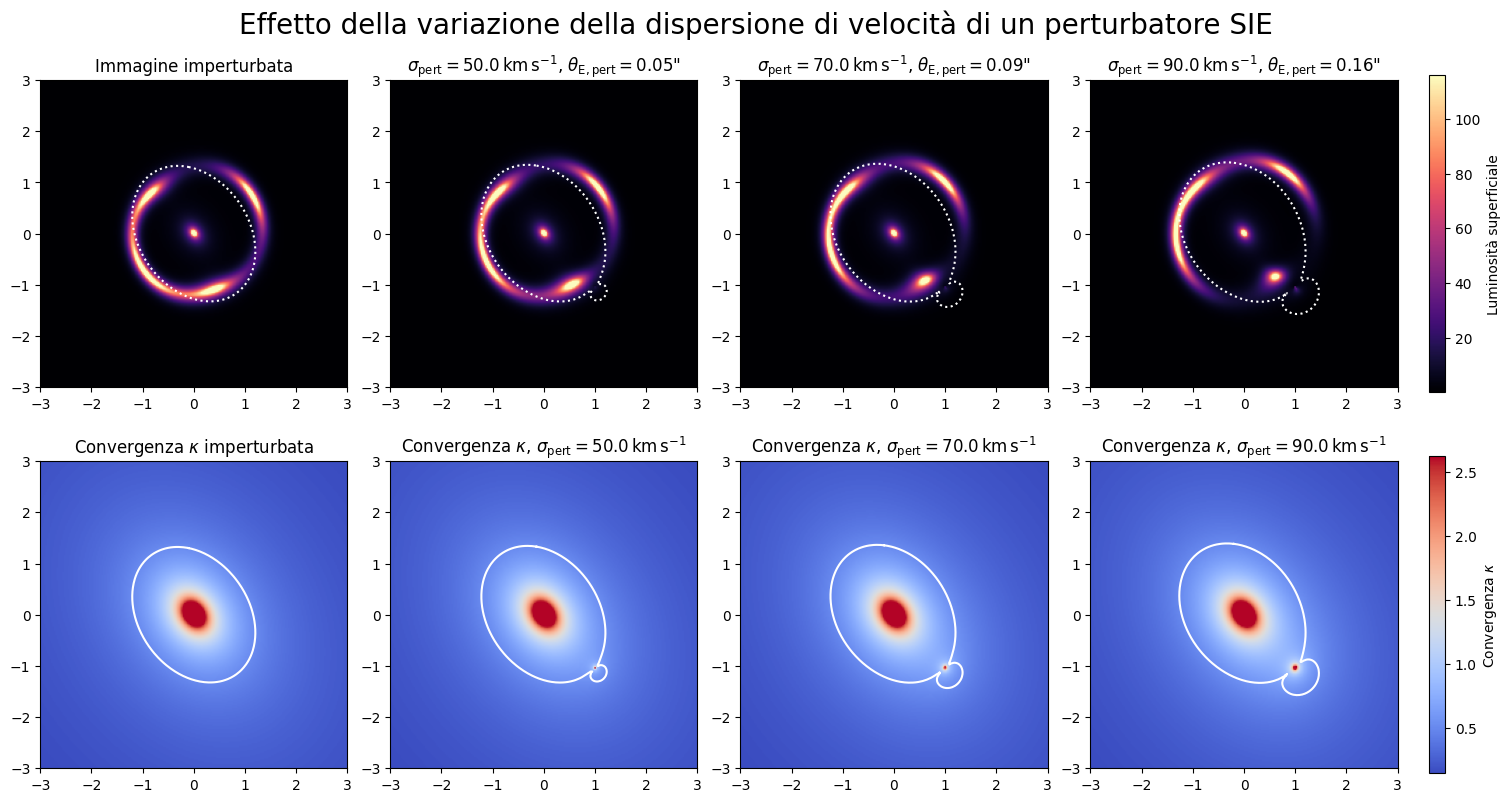

In [ ]:
source_unperturbed = sersic(size=fov, Npix=npix, gl=lens, save_unlensed=True, **source_kwargs)
total_image_unperturbed = source_unperturbed.image + lens_light.image

vmax_image_SIE = percentile_vmax(composite_total_images_all_SIE)
vmax_kappa_SIE = percentile_vmax(composite_kappa_maps_all_SIE)

fig3, ax3 = plt.subplots(2, 4, figsize=(15, 8), constrained_layout=True)

# Effect of varying the velocity dispersion of a SIE perturbator
fig3.suptitle("Effetto della variazione della dispersione di velocità di un perturbatore SIE", fontsize=20)

for ax in ax3.flat:
    ax.set_label("arcsec")
    ax.set_aspect("equal")

# Unperturbed references
ax3[0,0].set_title("Immagine imperturbata")
ax3[0,0].imshow(total_image_unperturbed, origin="lower", extent=extent, cmap="magma", vmax=vmax_image_SIE)
ax3[1,0].set_title('Convergenza $\kappa$ imperturbata')
ax3[1,0].imshow(lens.ka, origin="lower", extent=extent, cmap="coolwarm", vmax=vmax_kappa_SIE)
   
for xcritu, ycritu in critical_lines_lens:
    ax3[0,0].plot(xcritu, ycritu, color="white", linestyle="dotted")
    ax3[1,0].plot(xcritu, ycritu, color="white")

for i, sigma0_pert in enumerate(sigma0_values_pert):
    # Perturbed images and convergence maps 
    ax3[0,i+1].set_title(
        rf'$\sigma_\mathrm{{pert}}={sigma0_pert}\,\mathrm{{km\,s^{{-1}}}}$, '
        rf'$\theta_\mathrm{{E, pert}}={second_lens_SIE_all[i].bsie():.2f}$"')
    im0 = ax3[0, i+1].imshow(composite_total_images_all_SIE[i], origin="lower", extent=extent, cmap="magma", vmax=vmax_image_SIE)

    ax3[1,i+1].set_title(
        rf'Convergenza $\kappa$, $\sigma_\mathrm{{pert}}={sigma0_pert}\,\mathrm{{km\,s^{{-1}}}}$')
    im1 = ax3[1,i+1].imshow(composite_kappa_maps_all_SIE[i], origin="lower", extent=extent, cmap="coolwarm", vmax=vmax_kappa_SIE)


    for xcrit, ycrit in composite_critical_lines_SIE[i]:
        ax3[0,i+1].plot(xcrit, ycrit, color="white", linestyle="dotted")
        ax3[1,i+1].plot(xcrit, ycrit, color="white")

# Surface brightness
cbar0 = fig3.colorbar(
    im0,
    ax=ax3[0, :],
    shrink=0.85,
    pad=0.02
)
cbar0.set_label("Luminosità superficiale")

# Convergence
cbar1 = fig3.colorbar(
    im1,
    ax=ax3[1, :],
    shrink=0.85,
    pad=0.02
)
cbar1.set_label(r"Convergenza $\kappa$")


## Detectability threshold of the SIE perturber

In [92]:
sigma0_values_pert_var = [0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0]
second_lens_all_SIE_var = []
composite_lens_SIE_all_var = []
composite_critical_lines_SIE_var = []

for sigma0_pert_var in sigma0_values_pert_var:
    second_sie_kwargs_range = {
    "sigma0": sigma0_pert_var, 
    "q": 0.9,
    "pa": np.deg2rad(-20.0),
    "theta_c": 1.0e-4,
    "x1": pert_pos[0],
    "x2": pert_pos[1]
    }

    second_lens_SIE_var, lens_with_second_SIE_var = make_composite_lens(lens, "SIE", second_sie_kwargs_range, co, zl, zs, theta)
    
    second_lens_all_SIE_var.append(second_lens_SIE_var)
    composite_lens_SIE_all_var.append(lens_with_second_SIE_var)
    
    critical_lines_with_second_SIE_var = [lens_with_second_SIE_var.getCritPoints(cl) for cl in lens_with_second_SIE_var.tancl()]
    composite_critical_lines_SIE_var.append(critical_lines_with_second_SIE_var)
    
    # Numerical checks:
    print(f"Second SIE sigma0: {sigma0_pert_var} arcsec")
    print(f"Second SIE Einstein radius: {second_lens_SIE_var.bsie():.3f} arcsec")


composite_sources_SIE_var= []
composite_total_images_SIE_var = []
composite_kappa_maps_SIE_var = []
einstein_radii_pert = []

for i, pert_var in enumerate(second_lens_all_SIE_var):
    source_with_second_SIE_var = sersic(
    size=fov,
    Npix=npix,
    gl=composite_lens_SIE_all_var[i],
    save_unlensed=True,
    **source_kwargs,
    )
    composite_sources_SIE_var.append(source_with_second_SIE_var)
    composite_kappa_maps_SIE_var.append(composite_lens_SIE_all_var[i].ka)
    einstein_radii_pert.append(pert_var.bsie())

    total_image_with_second_SIE_var = source_with_second_SIE_var.image + lens_light.image
    composite_total_images_SIE_var.append(total_image_with_second_SIE_var)

    # Numerical checks
    print(f"Composite-lens source flux sum: {source_with_second_SIE_var.image.sum():.3e}")
    print(f"Change relative to original lens: "
      f"{source_with_second_SIE_var.image.sum() - source_unperturbed.image.sum():.3e}")


Second SIE sigma0: 0.0 arcsec
Second SIE Einstein radius: 0.000 arcsec
Second SIE sigma0: 10.0 arcsec
Second SIE Einstein radius: 0.002 arcsec
Second SIE sigma0: 20.0 arcsec
Second SIE Einstein radius: 0.008 arcsec
Second SIE sigma0: 30.0 arcsec
Second SIE Einstein radius: 0.017 arcsec
Second SIE sigma0: 40.0 arcsec
Second SIE Einstein radius: 0.031 arcsec
Second SIE sigma0: 50.0 arcsec
Second SIE Einstein radius: 0.048 arcsec
Second SIE sigma0: 60.0 arcsec
Second SIE Einstein radius: 0.070 arcsec
Second SIE sigma0: 70.0 arcsec
Second SIE Einstein radius: 0.095 arcsec
Second SIE sigma0: 80.0 arcsec
Second SIE Einstein radius: 0.124 arcsec
Second SIE sigma0: 90.0 arcsec
Second SIE Einstein radius: 0.156 arcsec
Composite-lens source flux sum: 1.959e+05
Change relative to original lens: 0.000e+00
Composite-lens source flux sum: 1.959e+05
Change relative to original lens: 1.300e+01
Composite-lens source flux sum: 1.959e+05
Change relative to original lens: -2.946e+01
Composite-lens source 

## Graph


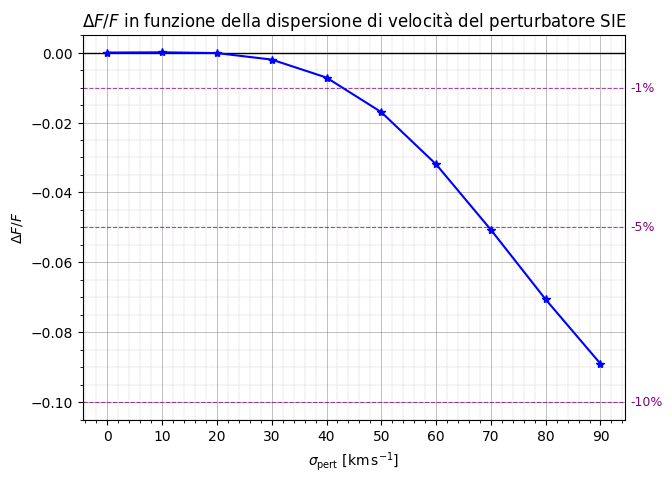

In [88]:
flux_ratios_SIE = []
for sws in composite_sources_SIE_var:
    flux_ratio_SIE = (
    sws.image.sum()
    - source_unperturbed.image.sum()
 ) / source_unperturbed.image.sum()
    flux_ratios_SIE.append(flux_ratio_SIE)


fig4, ax4 = plt.subplots(figsize=(7, 5))

# Percentages to highlight
percent_levels = [1, 5, 10] 

for p in percent_levels:

    level = p / 100

    # Negative levels
    ax4.axhline(
        -level,
        color="purple",
        linestyle="--",
        linewidth=0.8,
        alpha=0.7
    )
    # Negative Tags 
    ax4.text(
        1.01,
        -level,
        f"-{p}%",
        transform=ax4.get_yaxis_transform(),
        va="center",
        fontsize=9,
        color="purple"
    )


# Zero line
ax4.axhline(
    0,
    color="black",
    linestyle="-",
    linewidth=1
)

# Plotting the normalised difference in flux vs the velocity dispersion of the SIE perturber
ax4.plot(sigma0_values_pert_var, flux_ratios_SIE, marker='*', color="blue")
ax4.set_xlabel(r'$\sigma_{\mathrm{pert}}\ [\mathrm{km\,s^{-1}}]$')
ax4.set_ylabel(r'$\Delta F/F$')
ax4.set_title(r"$\Delta F/F$ in funzione della dispersione di velocità del perturbatore SIE")
ax4.minorticks_on()
ax4.grid(True, which='major', linestyle="-", linewidth=0.5,
        color="gray", alpha=0.7)
ax4.grid(True, which='minor', linestyle="--", linewidth=0.3,
        color="gray", alpha=0.5)
from matplotlib.ticker import MultipleLocator
ax4.xaxis.set_major_locator(MultipleLocator(10))

plt.show()


## Saving

In [ ]:
figure_path3 = outdir / "final_simulations_SIE.png" # Change the filename if you do not want to overwrite the existing file!
fig3.savefig(figure_path3, dpi=180)
print(f"Saved {figure_path3}")

figure_path4 = outdir / "final_simulations_SIE_graph.png" # Change the filename if you do not want to overwrite the existing file!
fig4.savefig(figure_path4, dpi=180)
print(f"Saved {figure_path4}")

Saved /home/sabrina-n/tesi-triennale/outputs/final_simulations_SIE.png
Saved /home/sabrina-n/tesi-triennale/outputs/final_simulations_SIE_graph.png


# NFW perutbator 

## Add a second NFW mass component

In [89]:
mass_values_all = [3.0e8, 4.0e9, 5.0e11]
second_lens_NFW_all = []
composite_lens_NFW_all = []
composite_critical_lines_NFW= []

for mass_value in mass_values_all:
    second_nfw_kwargs_var = {
    "mass": mass_value, 
    "conc": 11.0,
    "q": 0.95,
    "pa": np.deg2rad(-20.0),
    "x1": pert_pos[0],
    "x2": pert_pos[1],
}

    second_lens_NFW, lens_with_second_NFW = make_composite_lens(lens, "NFW", second_nfw_kwargs_var, co, zl, zs, theta)

    second_lens_NFW_all.append(second_lens_NFW)
    composite_lens_NFW_all.append(lens_with_second_NFW)

    critical_lines_with_second_NFW = [lens_with_second_NFW.getCritPoints(cl) for cl in lens_with_second_NFW.tancl()]
    composite_critical_lines_NFW.append(critical_lines_with_second_NFW)

# Numerical checks
for pert_nfw in second_lens_NFW_all:
    print(f"Added second NFW mass component at "f"({pert_nfw.x1:.2f}, {pert_nfw.x2:.2f}) arcsec")
    print(f"Second NFW mass: {pert_nfw.mass:.2e} Msun")
    print(f"Second NFW concentration: {pert_nfw.conc:.2f}")
    print(f"Second NFW scale radius: {pert_nfw.rs_as:.3f} arcsec")


Added second NFW mass component at (1.00, -1.05) arcsec
Second NFW mass: 3.00e+08 Msun
Second NFW concentration: 11.00
Second NFW scale radius: 0.172 arcsec
Added second NFW mass component at (1.00, -1.05) arcsec
Second NFW mass: 4.00e+09 Msun
Second NFW concentration: 11.00
Second NFW scale radius: 0.408 arcsec
Added second NFW mass component at (1.00, -1.05) arcsec
Second NFW mass: 5.00e+11 Msun
Second NFW concentration: 11.00
Second NFW scale radius: 2.038 arcsec


## Ray trace with the composite lenses

In [90]:
composite_sources_all_NFW= []
composite_total_images_all_NFW = []
composite_kappa_maps_all_NFW= []

for i, pert_nfw in enumerate(second_lens_NFW_all):
    source_with_second_NFW = sersic(
    size=fov,
    Npix=npix,
    gl=composite_lens_NFW_all[i],
    save_unlensed=True,
    **source_kwargs,
    )
    composite_sources_all_NFW.append(source_with_second_NFW)
    composite_kappa_maps_all_NFW.append(composite_lens_NFW_all[i].ka)

    total_image_with_second_NFW = source_with_second_NFW.image + lens_light.image
    composite_total_images_all_NFW.append(total_image_with_second_NFW)

    # Numerical checks
    print(f"Composite-lens source flux sum: {source_with_second_NFW.image.sum():.3e}")
    print(f"Change relative to original lens: "
      f"{source_with_second_NFW.image.sum() - source_unperturbed.image.sum():.3e}")

Composite-lens source flux sum: 1.958e+05
Change relative to original lens: -7.454e+01
Composite-lens source flux sum: 1.954e+05
Change relative to original lens: -5.119e+02
Composite-lens source flux sum: 1.840e+05
Change relative to original lens: -1.185e+04


## Visualize the lensing configuration

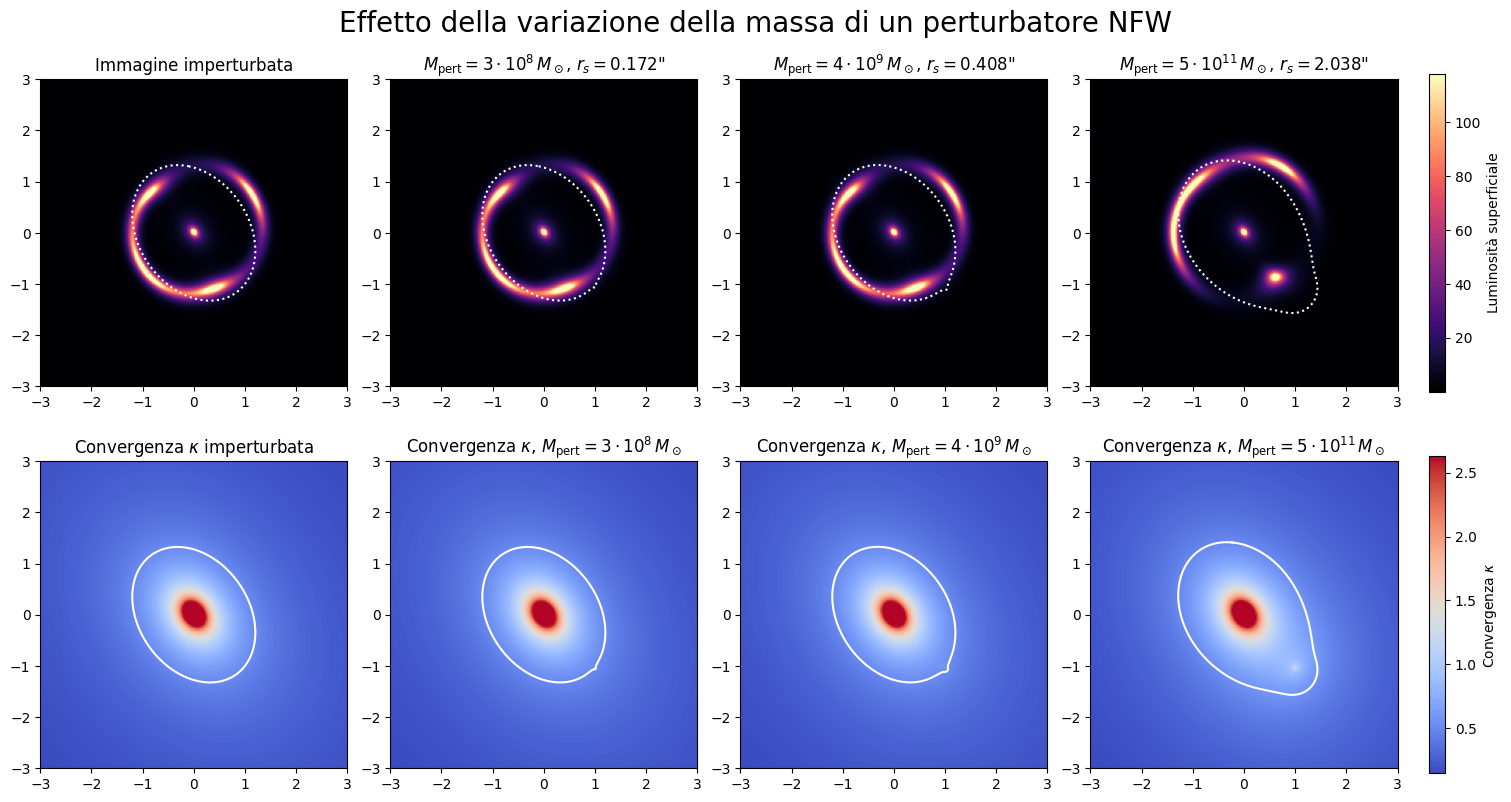

In [91]:
vmax_image_NFW = percentile_vmax(composite_total_images_all_NFW)
vmax_kappa_NFW = percentile_vmax(composite_kappa_maps_all_NFW)

fig5, ax5 = plt.subplots(2, 4, figsize=(15, 8), constrained_layout=True)

# Effect of varying the total mass of a NFW perturbator
fig5.suptitle("Effetto della variazione della massa di un perturbatore NFW", fontsize=20)

for ax in ax5.flat:
    ax.set_label("arcsec")
    ax.set_aspect("equal")

# Unperturbed references
ax5[0,0].set_title("Immagine imperturbata")
ax5[0,0].imshow(total_image_unperturbed, origin="lower", extent=extent, cmap="magma", vmax=vmax_image_NFW)
ax5[1,0].set_title('Convergenza $\kappa$ imperturbata')
ax5[1,0].imshow(lens.ka, origin="lower", extent=extent, cmap="coolwarm", vmax=vmax_kappa_NFW)

for xcritu, ycritu in critical_lines_lens:
    ax5[0,0].plot(xcritu, ycritu, color="white", linestyle="dotted")
    ax5[1,0].plot(xcritu, ycritu, color="white")


for i, mass_value in enumerate(mass_values_all):
    # Perturbed images and convergence maps
    esponente = int(np.floor(np.log10(abs(mass_value))))
    mantissa = mass_value / 10**esponente

    ax5[0,i+1].set_title(
        rf'$M_\mathrm{{pert}}={mantissa:g}\cdot 10^{{{esponente}}}\, M_\odot$, '
        rf'$r_s={second_lens_NFW_all[i].rs_as:.3f}$"')
    im0 = ax5[0,i+1].imshow(composite_total_images_all_NFW[i], origin="lower", extent=extent, cmap="magma", vmax=vmax_image_NFW)

    ax5[1,i+1].set_title(
        rf'Convergenza $\kappa$, $M_\mathrm{{pert}}={mantissa:g}\cdot 10^{{{esponente}}}\, M_\odot$')
    im1 = ax5[1,i+1].imshow(composite_kappa_maps_all_NFW[i], origin="lower", extent=extent, cmap="coolwarm", vmax=vmax_kappa_NFW)
 
    for xcrit, ycrit in composite_critical_lines_NFW[i]:
        ax5[0,i+1].plot(xcrit, ycrit, color="white", linestyle="dotted")
        ax5[1,i+1].plot(xcrit, ycrit, color="white")

# Surface brightness
cbar0 = fig5.colorbar(
    im0,
    ax=ax5[0, :],
    shrink=0.85,
    pad=0.02
)
cbar0.set_label("Luminosità superficiale")

# Convergence
cbar1 = fig5.colorbar(
    im1,
    ax=ax5[1, :],
    shrink=0.85,
    pad=0.02
)
cbar1.set_label(r"Convergenza $\kappa$")



## Detectability threshold of the NFW perturber

In [93]:
mass_values_var = [1.0e6, 1.0e7, 1.0e8, 5.0e8, 1.0e9, 5.0e9, 1.0e10, 3.0e10, 5.0e10, 7.0e10, 1.0e11]
second_lens_all_NFW_var = []
composite_lens_NFW_all_var = []
composite_critical_lines_NFW_var = []

for mass_value_var in mass_values_var:
    second_nfw_kwargs_range = {
    "mass": mass_value_var,
    "conc": 11.0,
    "q": 0.95,
    "pa": np.deg2rad(-20.0),
    "x1": pert_pos[0],
    "x2": pert_pos[1],
}

    second_lens_NFW_var, lens_with_second_NFW_var = make_composite_lens(lens, "NFW", second_nfw_kwargs_range, co, zl, zs, theta)
    
    second_lens_all_NFW_var.append(second_lens_NFW_var)
    composite_lens_NFW_all_var.append(lens_with_second_NFW_var)
    
    critical_lines_with_second_NFW_var = [lens_with_second_NFW_var.getCritPoints(cl) for cl in lens_with_second_NFW_var.tancl()]
    composite_critical_lines_NFW_var.append(critical_lines_with_second_NFW_var)
    
    # Numerical checks:
    print(f"Second NFW mass: {second_lens_NFW_var.mass:.2e} Msun")
    print(f"Second NFW scale radius: {second_lens_NFW_var.rs_as:.3f} arcsec")

composite_sources_NFW_var = []
composite_total_images_NFW_var = []
composite_kappa_maps_NFW_var = []

for i, pert_var in enumerate(second_lens_all_NFW_var):
    source_with_second_NFW_var = sersic(
    size=fov,
    Npix=npix,
    gl=composite_lens_NFW_all_var[i],
    save_unlensed=True,
    **source_kwargs
    )
    composite_sources_NFW_var.append(source_with_second_NFW_var)
    composite_kappa_maps_NFW_var.append(composite_lens_NFW_all_var[i].ka)

    total_image_with_second_NFW_var = source_with_second_NFW_var.image + lens_light.image
    composite_total_images_NFW_var.append(total_image_with_second_NFW_var)

    # Numerical checks
    print(f"Composite-lens source flux sum: {source_with_second_NFW_var.image.sum():.3e}")
    print(f"Change relative to original lens: "
      f"{source_with_second_NFW_var.image.sum() - source_unperturbed.image.sum():.3e}")

Second NFW mass: 1.00e+06 Msun
Second NFW scale radius: 0.026 arcsec
Second NFW mass: 1.00e+07 Msun
Second NFW scale radius: 0.055 arcsec
Second NFW mass: 1.00e+08 Msun
Second NFW scale radius: 0.119 arcsec
Second NFW mass: 5.00e+08 Msun
Second NFW scale radius: 0.204 arcsec
Second NFW mass: 1.00e+09 Msun
Second NFW scale radius: 0.257 arcsec
Second NFW mass: 5.00e+09 Msun
Second NFW scale radius: 0.439 arcsec
Second NFW mass: 1.00e+10 Msun
Second NFW scale radius: 0.553 arcsec
Second NFW mass: 3.00e+10 Msun
Second NFW scale radius: 0.798 arcsec
Second NFW mass: 5.00e+10 Msun
Second NFW scale radius: 0.946 arcsec
Second NFW mass: 7.00e+10 Msun
Second NFW scale radius: 1.058 arcsec
Second NFW mass: 1.00e+11 Msun
Second NFW scale radius: 1.192 arcsec
Composite-lens source flux sum: 1.959e+05
Change relative to original lens: -6.647e-01
Composite-lens source flux sum: 1.959e+05
Change relative to original lens: -4.782e+00
Composite-lens source flux sum: 1.959e+05
Change relative to origin

## Graph


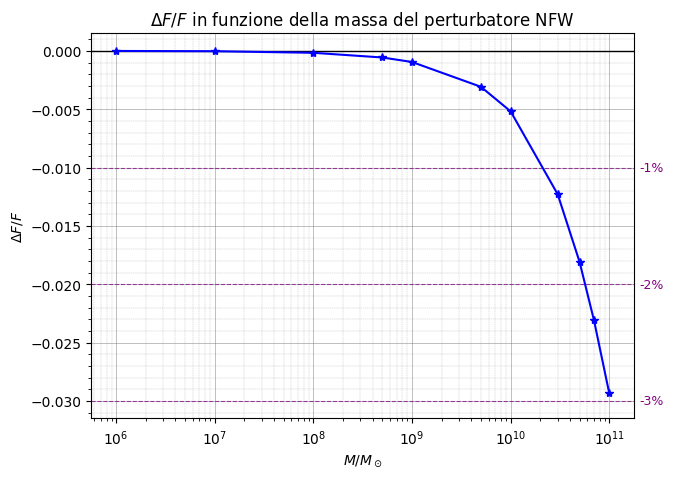

In [94]:
flux_ratios_NFW = []
for sws in composite_sources_NFW_var:
    flux_ratio_NFW = (
    sws.image.sum()
    - source_unperturbed.image.sum()
 ) / source_unperturbed.image.sum()
    flux_ratios_NFW.append(flux_ratio_NFW)


fig6, ax6 = plt.subplots(figsize=(7, 5))

# Percentages to highlight
percent_levels2 = [1, 2, 3]

for p2 in percent_levels2:

    level2 = p2 / 100

    # Negative levels
    ax6.axhline(
        -level2,
        color="purple",
        linestyle="--",
        linewidth=0.8,
        alpha=0.7
    )
    # Negative Tags
    ax6.text(
        1.01,
        -level2,
        f"-{p2}%",
        transform=ax6.get_yaxis_transform(),
        va="center",
        fontsize=9,
        color="purple"
    )


# Zero line
ax6.axhline(
    0,
    color="black",
    linestyle="-",
    linewidth=1
)

# Plotting the normalised difference in flux vs the mass of the NFW perturber
ax6.plot(mass_values_var, flux_ratios_NFW, marker='*', color="blue")
ax6.set_xlabel(r'$M/M_\odot$')
ax6.set_ylabel(r'$\Delta F/F$')
ax6.set_title(r"$\Delta F/F$ in funzione della massa del perturbatore NFW")
ax6.minorticks_on()
ax6.grid(True, which='major', linestyle="-", linewidth=0.5,
        color="gray", alpha=0.7)
ax6.grid(True, which='minor', linestyle="--", linewidth=0.3,
        color="gray", alpha=0.5)
ax6.set_xscale("log")

plt.show()

## Saving

In [95]:
figure_path5 = outdir / "final_simulations_NFW.png" # Change the filename if you do not want to overwrite the existing file!
fig5.savefig(figure_path5, dpi=180)
print(f"Saved {figure_path5}")

figure_path6 = outdir / "final_simulations_NFW_graph.png" # Change the filename if you do not want to overwrite the existing file!
fig6.savefig(figure_path6, dpi=180)
print(f"Saved {figure_path6}")

Saved /home/sabrina-n/tesi-triennale/outputs/final_simulations_NFW.png
Saved /home/sabrina-n/tesi-triennale/outputs/final_simulations_NFW_graph.png
